In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
concrete = np.loadtxt("concrete.csv", delimiter=",", skiprows=1)

X = concrete[:, :8]
y = concrete[:, 8]

In [3]:
def train_test_split(X, y, test_size=0.2, random_state=42):

    if random_state is not None:
        np.random.seed(random_state)

    n = X.shape[0]

    indices = np.random.permutation(n)

    split = int(n * (1 - test_size))

    train_idx = indices[:split]
    test_idx = indices[split:]

    X_train = X[train_idx]
    y_train = y[train_idx]

    X_test = X[test_idx]
    y_test = y[test_idx]

    return X_train, X_test, y_train, y_test

In [4]:
class StandardScaler:

    def fit(self, X):

        self.mean = np.mean(X, axis=0)
        self.std = np.std(X, axis=0)

        self.std[self.std == 0] = 1

    def transform(self, X):

        return (X - self.mean) / self.std

    def fit_transform(self, X):

        self.fit(X)

        return self.transform(X)

In [5]:
def rmse(y_true, y_pred):
    y_true = y_true.flatten()
    y_pred = y_pred.flatten()

    return np.sqrt(np.mean((y_true - y_pred) ** 2))

In [6]:
def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

In [7]:
def mre(y_true, y_pred):
    mask = y_true != 0
    return np.mean(
        (y_true[mask] - y_pred[mask]) / y_true[mask]
    )

# Questão 1

In [8]:
class MLP:

    def __init__(
        self,
        input_size,
        hidden_size,
        output_size,
        learning_rate=0.001,
        momentum=0.9,
        epochs=300,
        batch_size=32
    ):

        self.lr = learning_rate
        self.momentum = momentum
        self.epochs = epochs
        self.batch_size = batch_size

        self.W1 = np.random.randn(input_size, hidden_size) * 0.01
        self.b1 = np.zeros((1, hidden_size))

        self.W2 = np.random.randn(hidden_size, output_size) * 0.01
        self.b2 = np.zeros((1, output_size))

        self.vW1 = np.zeros_like(self.W1)
        self.vb1 = np.zeros_like(self.b1)

        self.vW2 = np.zeros_like(self.W2)
        self.vb2 = np.zeros_like(self.b2)

        self.train_losses = []
        self.val_losses = []

    def relu(self, x):

        return np.maximum(0, x)

    def relu_derivative(self, x):

        return (x > 0).astype(float)

    def forward(self, X):

        self.z1 = np.dot(X, self.W1) + self.b1

        self.a1 = self.relu(self.z1)

        self.z2 = np.dot(self.a1, self.W2) + self.b2

        return self.z2

    def compute_loss(self, y_true, y_pred):

        return np.mean((y_true - y_pred) ** 2)

    def backward(self, X, y, y_pred):

        m = X.shape[0]

        dz2 = (2 / m) * (y_pred - y)

        dW2 = np.dot(self.a1.T, dz2)
        db2 = np.sum(dz2, axis=0, keepdims=True)

        da1 = np.dot(dz2, self.W2.T)

        dz1 = da1 * self.relu_derivative(self.z1)

        dW1 = np.dot(X.T, dz1)
        db1 = np.sum(dz1, axis=0, keepdims=True)

        self.vW2 = self.momentum * self.vW2 - self.lr * dW2
        self.vb2 = self.momentum * self.vb2 - self.lr * db2

        self.vW1 = self.momentum * self.vW1 - self.lr * dW1
        self.vb1 = self.momentum * self.vb1 - self.lr * db1

        self.W2 += self.vW2
        self.b2 += self.vb2

        self.W1 += self.vW1
        self.b1 += self.vb1

    def fit(self, X_train, y_train, X_val, y_val):

        n_samples = X_train.shape[0]

        for epoch in range(self.epochs):

            indices = np.arange(n_samples)

            np.random.shuffle(indices)

            X_train = X_train[indices]
            y_train = y_train[indices]

            for i in range(0, n_samples, self.batch_size):

                X_batch = X_train[i:i+self.batch_size]
                y_batch = y_train[i:i+self.batch_size]

                y_pred = self.forward(X_batch)

                self.backward(X_batch, y_batch, y_pred)

            train_pred = self.forward(X_train)

            train_loss = self.compute_loss(
                y_train,
                train_pred
            )

            self.train_losses.append(train_loss)

            val_pred = self.forward(X_val)

            val_loss = self.compute_loss(
                y_val,
                val_pred
            )

            self.val_losses.append(val_loss)

            if epoch % 20 == 0:

                print(
                    f"Época {epoch} | "
                    f"Train Loss = {train_loss:.4f} | "
                    f"Val Loss = {val_loss:.4f}"
                )

    def predict(self, X):

        return self.forward(X)

In [9]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.25,
    random_state=42
)

In [10]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [11]:
y_train = y_train.reshape(-1, 1)
y_val = y_val.reshape(-1, 1)
y_test = y_test.reshape(-1, 1)

In [12]:
hidden_options = [10, 20, 30]
learning_rates = [0.001, 0.01]
best_model = None
best_rmse = np.inf
best_hidden = None
best_lr = None

In [13]:
for hidden_size in hidden_options:

    for lr in learning_rates:

        print("\n===================================")
        print(f"Hidden Size = {hidden_size}")
        print(f"Learning Rate = {lr}")
        print("===================================\n")

        model = MLP(
            input_size=X_train.shape[1],
            hidden_size=hidden_size,
            output_size=1,
            learning_rate=lr,
            momentum=0.9,
            epochs=300,
            batch_size=32
        )

        model.fit(
            X_train,
            y_train,
            X_val,
            y_val
        )

        val_pred = model.predict(X_val)

        current_rmse = rmse(y_val, val_pred)

        print(f"Validation RMSE = {current_rmse:.4f}")

        if current_rmse < best_rmse:

            best_rmse = current_rmse
            best_model = model
            best_hidden = hidden_size
            best_lr = lr


Hidden Size = 10
Learning Rate = 0.001

Época 0 | Train Loss = 997.1077 | Val Loss = 993.5750
Época 20 | Train Loss = 112.4442 | Val Loss = 140.7913
Época 40 | Train Loss = 96.9889 | Val Loss = 115.8550
Época 60 | Train Loss = 102.5430 | Val Loss = 117.3166
Época 80 | Train Loss = 94.0272 | Val Loss = 124.8395
Época 100 | Train Loss = 94.4086 | Val Loss = 119.2147
Época 120 | Train Loss = 102.7426 | Val Loss = 108.3514
Época 140 | Train Loss = 93.4536 | Val Loss = 116.6844
Época 160 | Train Loss = 97.4222 | Val Loss = 111.0564
Época 180 | Train Loss = 93.2144 | Val Loss = 120.7064
Época 200 | Train Loss = 92.9456 | Val Loss = 113.7578
Época 220 | Train Loss = 103.7344 | Val Loss = 116.1958
Época 240 | Train Loss = 95.5082 | Val Loss = 119.9765
Época 260 | Train Loss = 103.0693 | Val Loss = 139.2508
Época 280 | Train Loss = 94.8969 | Val Loss = 109.9495
Validation RMSE = 10.5899

Hidden Size = 10
Learning Rate = 0.01

Época 0 | Train Loss = 281.8483 | Val Loss = 274.5507
Época 20 | Tra

In [14]:
print("\nMelhores hiperparâmetros:")
print("Hidden Size:", best_hidden)
print("Learning Rate:", best_lr)
print("Best Validation RMSE:", best_rmse)


Melhores hiperparâmetros:
Hidden Size: 20
Learning Rate: 0.001
Best Validation RMSE: 6.983336150761056


### Letra B

In [15]:
y_train_pred = best_model.predict(X_train)

y_test_pred = best_model.predict(X_test)

In [16]:
y_val_pred = best_model.predict(X_val)

print("\n==============================")
print("VALIDAÇÃO")
print("==============================")

print("RMSE:", rmse(y_val, y_val_pred))
print("MAE :", mae(y_val, y_val_pred))
print("MRE :", mre(y_val, y_val_pred))


VALIDAÇÃO
RMSE: 6.983336150761056
MAE : 5.512955338414048
MRE : -0.00602245163852415


In [17]:
print("\n==============================")
print("TREINO")
print("==============================")

print("RMSE:", rmse(y_train, y_train_pred))
print("MAE :", mae(y_train, y_train_pred))
print("MRE :", mre(y_train, y_train_pred))


TREINO
RMSE: 6.204275971410418
MAE : 4.757847269344033
MRE : -0.008574498440683477


In [18]:
print("\n==============================")
print("TESTE")
print("==============================")

print("RMSE:", rmse(y_test, y_test_pred))
print("MAE :", mae(y_test, y_test_pred))
print("MRE :", mre(y_test, y_test_pred))


TESTE
RMSE: 6.342673892572084
MAE : 5.091538217426739
MRE : -0.023771227922554403


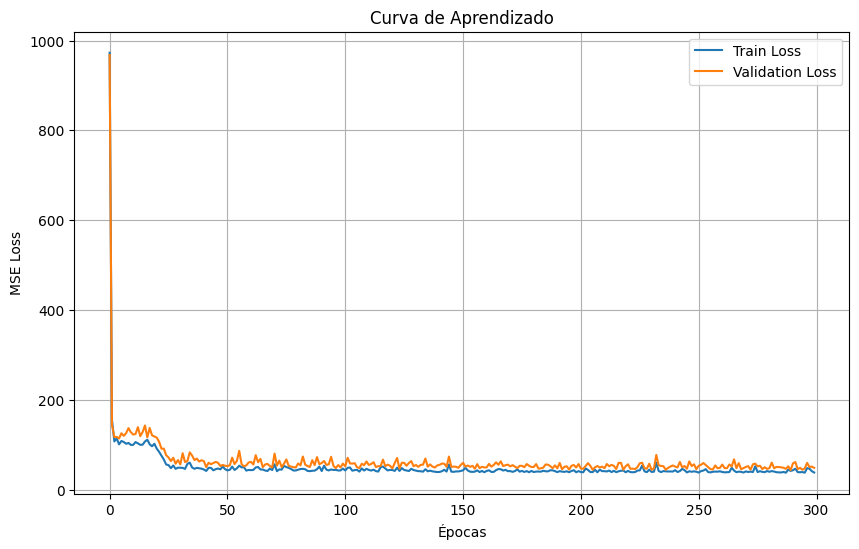

In [19]:
plt.figure(figsize=(10, 6))

plt.plot(
    best_model.train_losses,
    label="Train Loss"
)

plt.plot(
    best_model.val_losses,
    label="Validation Loss"
)

plt.xlabel("Épocas")

plt.ylabel("MSE Loss")

plt.title("Curva de Aprendizado")

plt.legend()

plt.grid(True)

plt.show()

# Questão 02

In [20]:
vehicle = np.loadtxt("vehicle.csv", delimiter=",", skiprows=1)
X = vehicle[:, :18]

y = vehicle[:, 18]

In [21]:
def confusion_matrix_elements(y_true, y_pred):
    TP = np.sum((y_true == 1) & (y_pred == 1))
    TN = np.sum((y_true == 0) & (y_pred == 0))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0))
    
    return TP, TN, FP, FN

In [22]:
def accuracy_score(y_true, y_pred):
    TP, TN, FP, FN = confusion_matrix_elements(y_true, y_pred)
    return (TP + TN) / (TP + TN + FP + FN)

In [23]:
def precision_score_macro(y_true, y_pred):

    classes = np.unique(y_true)

    precisions = []

    for cls in classes:

        TP = np.sum((y_true == cls) & (y_pred == cls))

        FP = np.sum((y_true != cls) & (y_pred == cls))

        if TP + FP == 0:
            precisions.append(0)
        else:
            precisions.append(TP / (TP + FP))

    return np.mean(precisions)

In [24]:
def recall_score_macro(y_true, y_pred):

    classes = np.unique(y_true)

    recalls = []

    for cls in classes:

        TP = np.sum((y_true == cls) & (y_pred == cls))

        FN = np.sum((y_true == cls) & (y_pred != cls))

        if TP + FN == 0:
            recalls.append(0)
        else:
            recalls.append(TP / (TP + FN))

    return np.mean(recalls)

In [25]:
def f1_score_macro(y_true, y_pred):

    precision = precision_score_macro(y_true, y_pred)

    recall = recall_score_macro(y_true, y_pred)

    if precision + recall == 0:
        return 0

    return 2 * (precision * recall) / (precision + recall)

In [26]:
def confusion_matrix_multiclass(y_true, y_pred, num_classes):

    matrix = np.zeros(
        (num_classes, num_classes),
        dtype=int
    )

    for t, p in zip(y_true, y_pred):

        matrix[t][p] += 1

    return matrix

### Letra A

In [27]:
vehicle = np.loadtxt(
    "vehicle.csv",
    delimiter=",",
    skiprows=1,
    dtype=str
)

X = vehicle[:, :18].astype(float)
y = vehicle[:, 18]

In [28]:
classes = np.unique(y)

class_to_index = {
    cls: idx for idx, cls in enumerate(classes)
}

index_to_class = {
    idx: cls for cls, idx in class_to_index.items()
}

y = np.array([class_to_index[label] for label in y])

num_classes = len(classes)

In [29]:
def one_hot(y, num_classes):

    onehot = np.zeros((len(y), num_classes))

    onehot[np.arange(len(y)), y] = 1

    return onehot

In [30]:
class MLPClassifier:

    def __init__(
        self,
        input_size,
        hidden_size,
        output_size,
        learning_rate=0.001,
        momentum=0.9,
        epochs=300,
        batch_size=32
    ):

        self.lr = learning_rate
        self.momentum = momentum
        self.epochs = epochs
        self.batch_size = batch_size

        self.W1 = np.random.randn(
            input_size,
            hidden_size
        ) * 0.01

        self.b1 = np.zeros((1, hidden_size))

        self.W2 = np.random.randn(
            hidden_size,
            output_size
        ) * 0.01

        self.b2 = np.zeros((1, output_size))

        self.vW1 = np.zeros_like(self.W1)
        self.vb1 = np.zeros_like(self.b1)

        self.vW2 = np.zeros_like(self.W2)
        self.vb2 = np.zeros_like(self.b2)

        self.train_losses = []
        self.val_losses = []

    def relu(self, x):

        return np.maximum(0, x)

    def relu_derivative(self, x):

        return (x > 0).astype(float)

    def softmax(self, x):

        exp_x = np.exp(
            x - np.max(x, axis=1, keepdims=True)
        )

        return exp_x / np.sum(
            exp_x,
            axis=1,
            keepdims=True
        )

    def forward(self, X):

        self.z1 = np.dot(X, self.W1) + self.b1

        self.a1 = self.relu(self.z1)

        self.z2 = np.dot(self.a1, self.W2) + self.b2

        self.output = self.softmax(self.z2)

        return self.output

    def compute_loss(self, y_true, y_pred):

        epsilon = 1e-15

        y_pred = np.clip(
            y_pred,
            epsilon,
            1 - epsilon
        )

        return -np.mean(
            np.sum(y_true * np.log(y_pred), axis=1)
        )


    def backward(self, X, y, y_pred):

        m = X.shape[0]

        dz2 = (y_pred - y) / m

        dW2 = np.dot(self.a1.T, dz2)

        db2 = np.sum(
            dz2,
            axis=0,
            keepdims=True
        )

        da1 = np.dot(dz2, self.W2.T)

        dz1 = da1 * self.relu_derivative(self.z1)

        dW1 = np.dot(X.T, dz1)

        db1 = np.sum(
            dz1,
            axis=0,
            keepdims=True
        )

        self.vW2 = (
            self.momentum * self.vW2
            - self.lr * dW2
        )

        self.vb2 = (
            self.momentum * self.vb2
            - self.lr * db2
        )

        self.vW1 = (
            self.momentum * self.vW1
            - self.lr * dW1
        )

        self.vb1 = (
            self.momentum * self.vb1
            - self.lr * db1
        )

        self.W2 += self.vW2
        self.b2 += self.vb2

        self.W1 += self.vW1
        self.b1 += self.vb1

    def fit(
        self,
        X_train,
        y_train,
        X_val,
        y_val
    ):

        n_samples = X_train.shape[0]

        for epoch in range(self.epochs):

            indices = np.arange(n_samples)

            np.random.shuffle(indices)

            X_train = X_train[indices]
            y_train = y_train[indices]

            for i in range(
                0,
                n_samples,
                self.batch_size
            ):

                X_batch = X_train[
                    i:i+self.batch_size
                ]

                y_batch = y_train[
                    i:i+self.batch_size
                ]

                y_pred = self.forward(X_batch)

                self.backward(
                    X_batch,
                    y_batch,
                    y_pred
                )

            train_pred = self.forward(X_train)

            train_loss = self.compute_loss(
                y_train,
                train_pred
            )

            self.train_losses.append(train_loss)

            val_pred = self.forward(X_val)

            val_loss = self.compute_loss(
                y_val,
                val_pred
            )

            self.val_losses.append(val_loss)

            if epoch % 20 == 0:

                print(
                    f"Época {epoch} | "
                    f"Train Loss = {train_loss:.4f} | "
                    f"Val Loss = {val_loss:.4f}"
                )

    def predict(self, X):

        probs = self.forward(X)

        return np.argmax(probs, axis=1)

In [31]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.25,
    random_state=42
)

In [32]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_val = scaler.transform(X_val)

X_test = scaler.transform(X_test)

y_train_onehot = one_hot(y_train, num_classes)

y_val_onehot = one_hot(y_val, num_classes)

y_test_onehot = one_hot(y_test, num_classes)

In [33]:
hidden_options = [10, 20, 30]

learning_rates = [0.001, 0.01]

best_model = None

best_acc = -np.inf

best_hidden = None

best_lr = None

In [34]:
for hidden_size in hidden_options:

    for lr in learning_rates:

        print("\n===================================")
        print(f"Hidden Size = {hidden_size}")
        print(f"Learning Rate = {lr}")
        print("===================================\n")

        model = MLPClassifier(
            input_size=X_train.shape[1],
            hidden_size=hidden_size,
            output_size=num_classes,
            learning_rate=lr,
            momentum=0.9,
            epochs=300,
            batch_size=32
        )

        model.fit(
            X_train,
            y_train_onehot,
            X_val,
            y_val_onehot
        )

        val_pred = model.predict(X_val)

        current_acc = accuracy_score(
            y_val,
            val_pred
        )

        print(
            f"Validation Accuracy = "
            f"{current_acc:.4f}"
        )

        if current_acc > best_acc:

            best_acc = current_acc

            best_model = model

            best_hidden = hidden_size

            best_lr = lr


Hidden Size = 10
Learning Rate = 0.001

Época 0 | Train Loss = 1.3862 | Val Loss = 1.3868
Época 20 | Train Loss = 1.3832 | Val Loss = 1.3923
Época 40 | Train Loss = 1.3689 | Val Loss = 1.3833
Época 60 | Train Loss = 1.3011 | Val Loss = 1.3229
Época 80 | Train Loss = 1.2194 | Val Loss = 1.2457
Época 100 | Train Loss = 1.1188 | Val Loss = 1.1453
Época 120 | Train Loss = 0.9925 | Val Loss = 1.0125
Época 140 | Train Loss = 0.8850 | Val Loss = 0.9048
Época 160 | Train Loss = 0.7997 | Val Loss = 0.8219
Época 180 | Train Loss = 0.7319 | Val Loss = 0.7576
Época 200 | Train Loss = 0.6759 | Val Loss = 0.6995
Época 220 | Train Loss = 0.6295 | Val Loss = 0.6501
Época 240 | Train Loss = 0.5884 | Val Loss = 0.6062
Época 260 | Train Loss = 0.5554 | Val Loss = 0.5758
Época 280 | Train Loss = 0.5284 | Val Loss = 0.5505
Validation Accuracy = 1.0000

Hidden Size = 10
Learning Rate = 0.01

Época 0 | Train Loss = 1.3853 | Val Loss = 1.3886
Época 20 | Train Loss = 0.6579 | Val Loss = 0.6679
Época 40 | Trai

In [35]:
print("\n===================================")
print("Melhores hiperparâmetros")
print("===================================")

print("Hidden Size:", best_hidden)

print("Learning Rate:", best_lr)

print("Best Validation Accuracy:", best_acc)


Melhores hiperparâmetros
Hidden Size: 10
Learning Rate: 0.001
Best Validation Accuracy: 1.0


### Letra B

In [36]:
y_train_pred = best_model.predict(X_train)

y_val_pred = best_model.predict(X_val)

y_test_pred = best_model.predict(X_test)

In [37]:
def print_metrics(y_true, y_pred, name):

    print("\n==============================")
    print(name)
    print("==============================")

    print(
        "Accuracy:",
        accuracy_score(y_true, y_pred)
    )

    print(
        "Precision Macro:",
        precision_score_macro(y_true, y_pred)
    )

    print(
        "Recall Macro:",
        recall_score_macro(y_true, y_pred)
    )

    print(
        "F1-score Macro:",
        f1_score_macro(y_true, y_pred)
    )

In [38]:
print_metrics(
    y_val,
    y_val_pred,
    "VALIDAÇÃO"
)


VALIDAÇÃO
Accuracy: 1.0
Precision Macro: 0.7229868614112311
Recall Macro: 0.7442943191865605
F1-score Macro: 0.7334858797489171


In [39]:
cm = confusion_matrix_multiclass(
    y_test,
    y_test_pred,
    num_classes
)

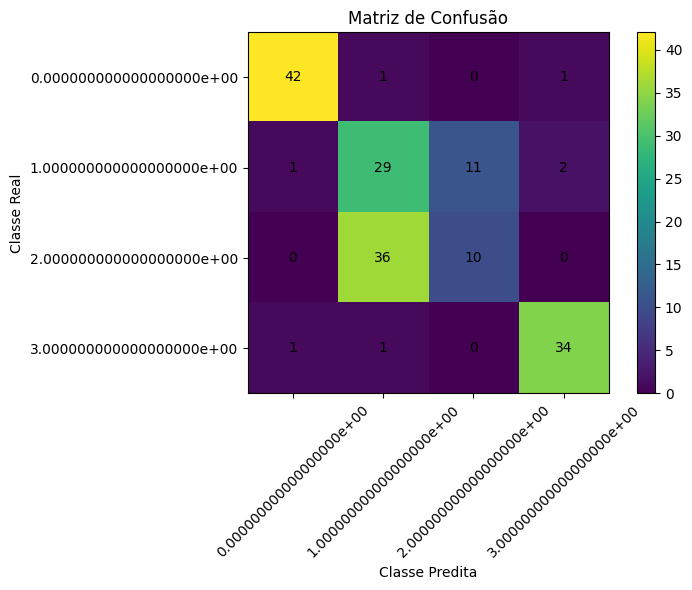

In [42]:
plt.figure(figsize=(8, 6))

plt.imshow(cm, interpolation='nearest')

plt.title("Matriz de Confusão")

plt.colorbar()

tick_marks = np.arange(num_classes)

plt.xticks(
    tick_marks,
    classes,
    rotation=45
)

plt.yticks(
    tick_marks,
    classes
)

for i in range(num_classes):
    for j in range(num_classes):

        plt.text(
            j,
            i,
            str(cm[i, j]),
            ha='center',
            va='center'
        )

plt.xlabel("Classe Predita")

plt.ylabel("Classe Real")

plt.tight_layout()

plt.show()

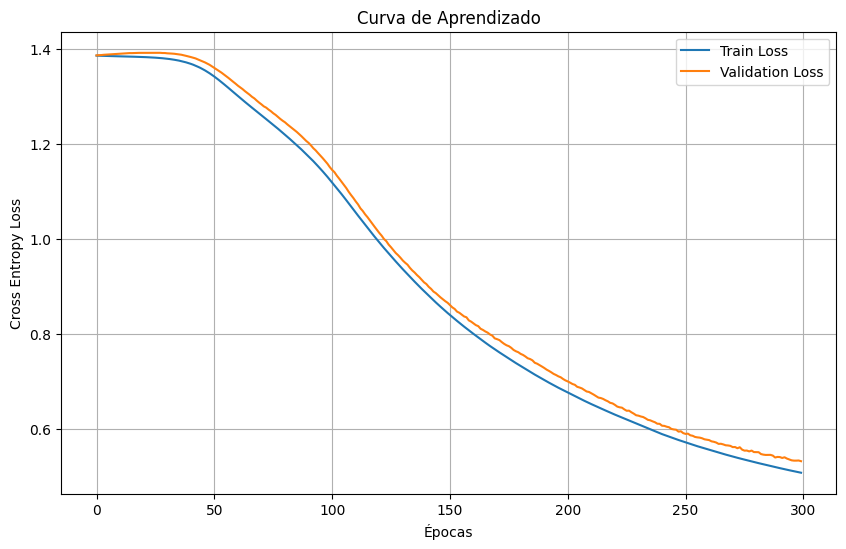

In [40]:
plt.figure(figsize=(10, 6))

plt.plot(
    best_model.train_losses,
    label="Train Loss"
)

plt.plot(
    best_model.val_losses,
    label="Validation Loss"
)

plt.xlabel("Épocas")

plt.ylabel("Cross Entropy Loss")

plt.title("Curva de Aprendizado")

plt.legend()

plt.grid(True)

plt.show()